# Model 1B — P(Ro | log_τ_cE, log_σ_τ_cE, log_age)

**Variant 1B**: inverse age uncertainty loss weighting.

Flow x (density variable): `log_rossby = log_prot − log_tau_ce`  
Conditioning vector: `[log_age_myr, log_tau_ce, log_tau_ce_err]`  
Loss: `w_total = W_F * w_age_i` where `w_age_i = (1/(err_lo+err_hi)) / mean(1/(err_lo+err_hi))`

Motivation: the Rossby number Ro = P_rot / τ_cE captures the magnetic dynamo physics more directly
than P_rot alone. Modeling P(Ro | age, τ_cE) tests whether the Rossby number representation
improves age inference over the raw rotation period.

Note: τ_cE is held constant below 0.18 M☉ in the Gossage table (~3.6% of training stars).

Training set: 5846 stars (273 with missing age uncertainty dropped — required for loss weighting).  
At inference: fix observed (log_Ro, log_τ_cE, log_σ_τ_cE), sweep log_age → posterior P(age | Ro, τ_cE, σ_τ_cE).

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import torch
import pickle
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 120

from training.constants import LOGA_GRID, PRIOR_LOGROSSBY
from training.data     import load_training
from training.kfold    import run_kfold
from training.infer    import batch_posteriors
from training.metrics  import compute_residuals
from training.report   import training_report, kfold_report, posterior_report, prot_space_report

## 1. Load data

In [2]:
df = load_training('../../cf_data/training_stars.csv', drop_nan_age_err=True)
print(f'Total stars: {len(df)}')
print(f'Clusters: {df["source_paper"].nunique()}')
print(f'log_rossby range: {df["log_rossby"].min():.2f} to {df["log_rossby"].max():.2f}')
df[['log_prot', 'log_age_myr', 'log_tau_ce', 'log_tau_ce_err', 'log_rossby']].describe()

Total stars: 5846
Clusters: 20
log_rossby range: -3.37 to 0.57


,log_prot,log_age_myr,log_tau_ce,log_tau_ce_err,log_rossby
count,5846.000000,5846.000000,5846.000000,5846.000000,5846.000000
mean,0.276234,2.128005,1.957213,0.908705,-1.680979
std,0.571320,0.654343,0.280855,0.481761,0.717436
min,-1.084073,0.176091,1.562228,0.250505,-3.365468
25%,-0.152376,1.653213,1.711497,0.523649,-2.250273
50%,0.186679,2.123852,1.877709,0.741886,-1.744642
75%,0.656998,2.599883,2.297012,1.489958,-1.124405
max,2.241546,4.060698,2.379666,1.695817,0.566530


## 2. Define conditioning columns

In [3]:
OBS_COL   = 'log_rossby'
COND_COLS = ['log_age_myr', 'log_tau_ce', 'log_tau_ce_err']
N_FOLDS   = 5
STEPS     = 5000

print('Observable:', OBS_COL)
print('Conditioning vector size:', len(COND_COLS))
print('Columns:', COND_COLS)
print('Prior bounds on log_rossby:', PRIOR_LOGROSSBY)

Observable: log_rossby
Conditioning vector size: 3
Columns: ['log_age_myr', 'log_tau_ce', 'log_tau_ce_err']
Prior bounds on log_rossby: (-3.5, 1.0)


## 3. K-fold training

In [4]:
import importlib, training.kfold
importlib.reload(training.kfold)
from training.kfold import run_kfold

results_df, fold_flows, fold_scalers, loss_curves, posteriors_kfold = run_kfold(
    df           = df,
    obs_col      = OBS_COL,
    cond_cols    = COND_COLS,
    n_folds      = N_FOLDS,
    steps        = STEPS,
    age_weights  = True,
    prior_bounds = PRIOR_LOGROSSBY,
)


=== Fold 1 / 5 ===
step     0  loss 1.326802
step  1000  loss 0.066949
step  2000  loss 0.041150
step  3000  loss 0.031634
step  4000  loss 0.030152
step  5000  loss 0.029491

=== Fold 2 / 5 ===
step     0  loss 1.296771
step  1000  loss 0.084261
step  2000  loss 0.067362
step  3000  loss 0.057048
step  4000  loss 0.055991
step  5000  loss 0.055420

=== Fold 3 / 5 ===
step     0  loss 1.283145
step  1000  loss 0.078296
step  2000  loss 0.051497
step  3000  loss 0.038532
step  4000  loss 0.037104
step  5000  loss 0.036408

=== Fold 4 / 5 ===
step     0  loss 1.297564
step  1000  loss 0.075741
step  2000  loss 0.052410
step  3000  loss 0.042339
step  4000  loss 0.040651
step  5000  loss 0.039912

=== Fold 5 / 5 ===
step     0  loss 1.282521
step  1000  loss 0.063192
step  2000  loss 0.032972
step  3000  loss 0.020826
step  4000  loss 0.018803
step  5000  loss 0.017697


## 4. Training loss

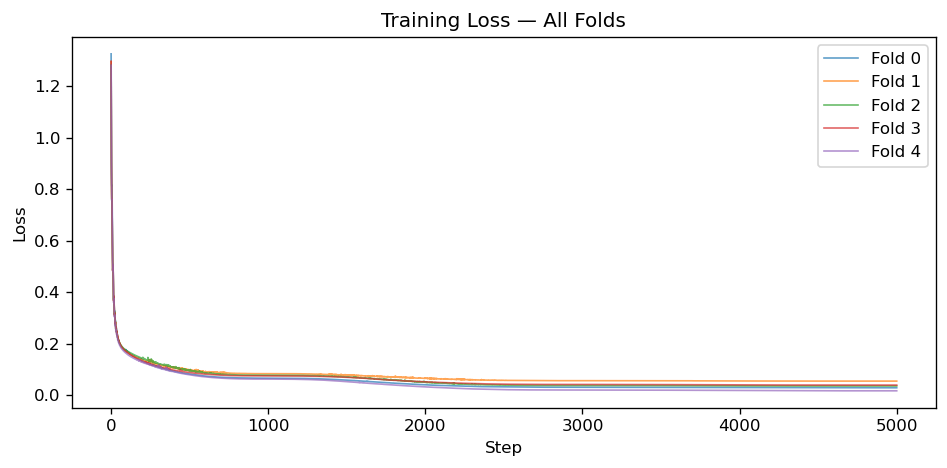

In [5]:
training_report(loss_curves)

## 5. Residual diagnostics

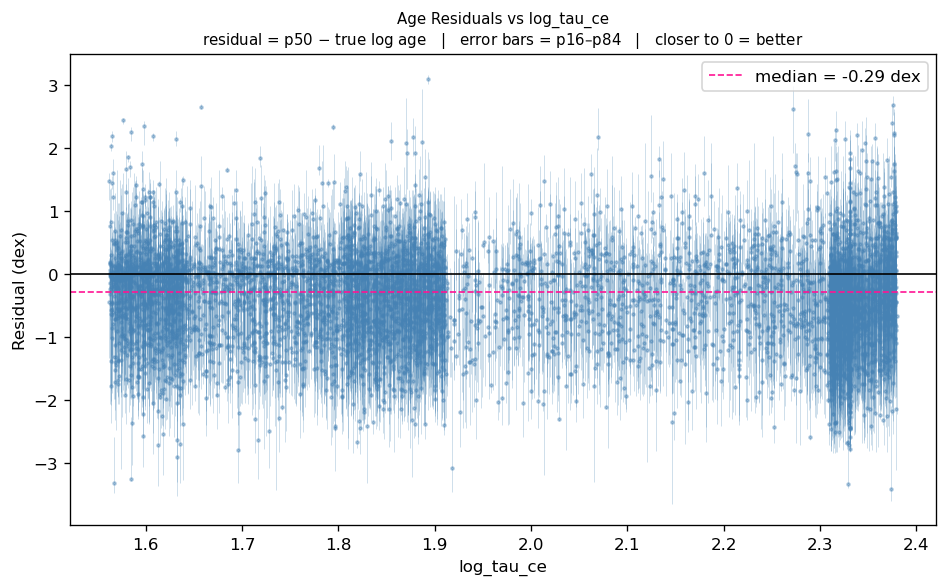

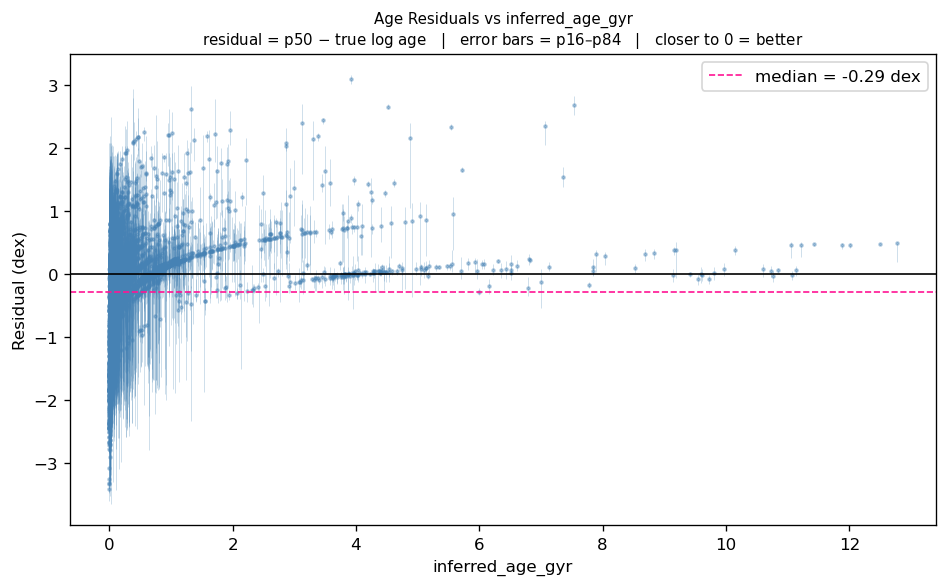

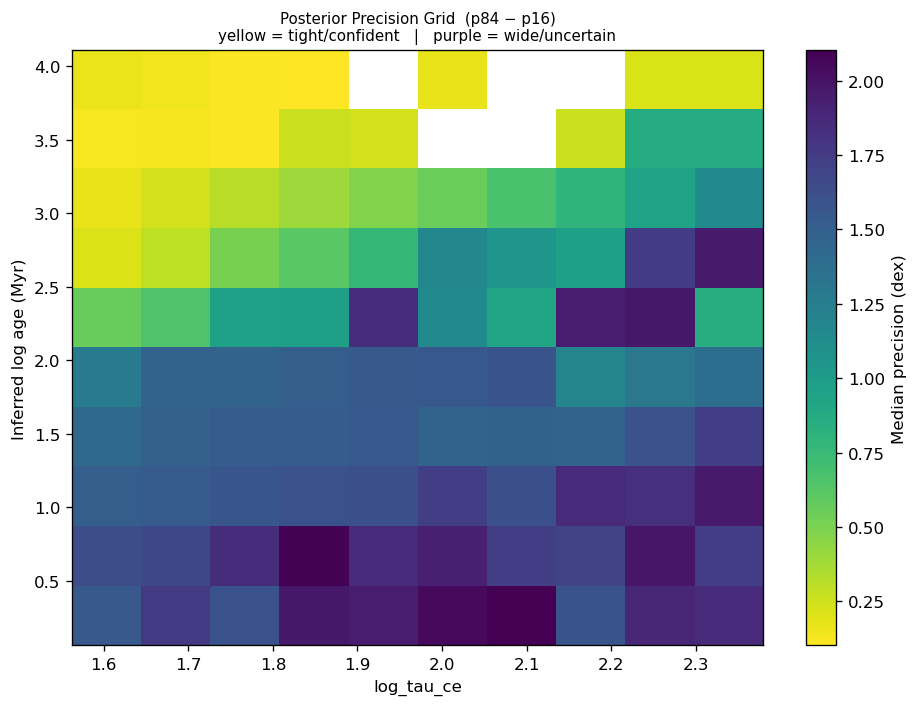

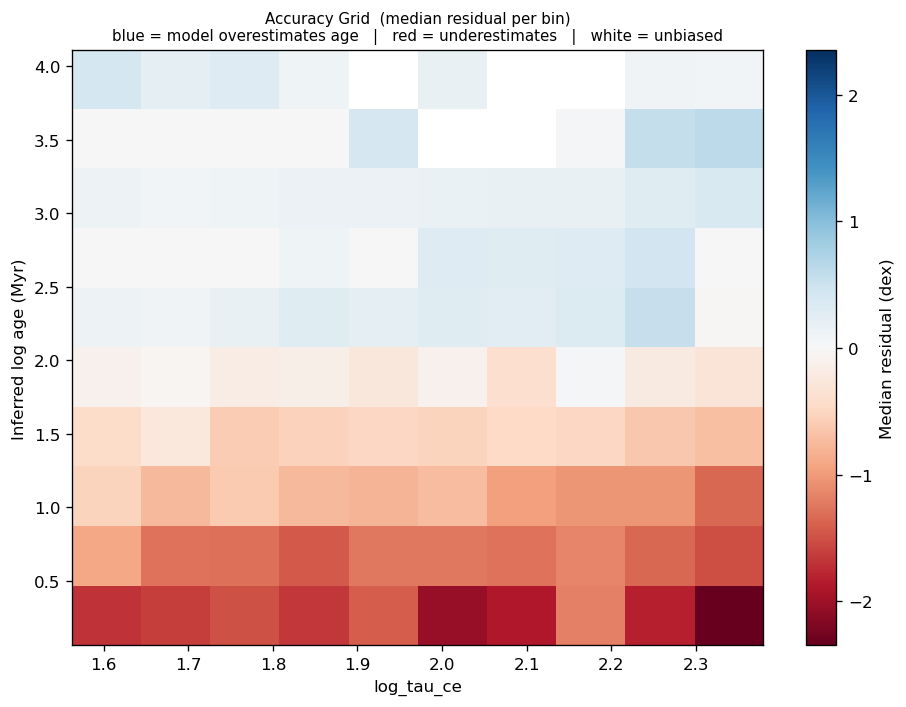

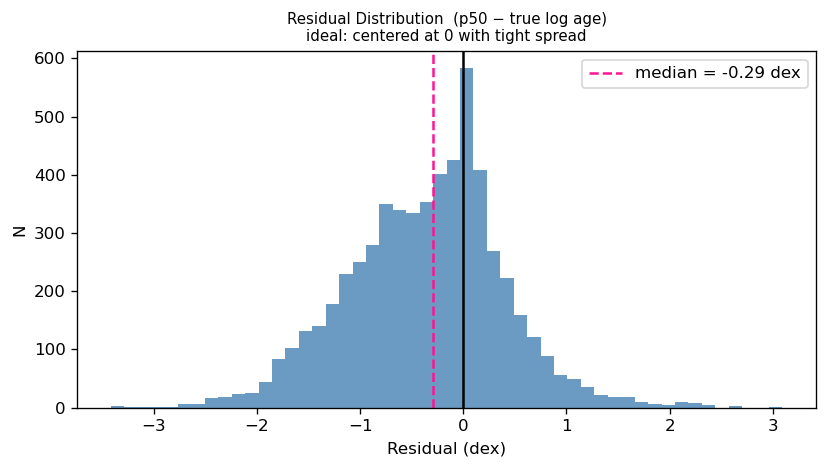

In [6]:
import importlib
import training.plots, training.report
importlib.reload(training.plots)
importlib.reload(training.report)
from training.report import kfold_report

kfold_report(results_df, x_col='log_tau_ce')

## 6. Held-out posteriors (each star evaluated on its val fold)

Posteriors shape: (5846, 1000)


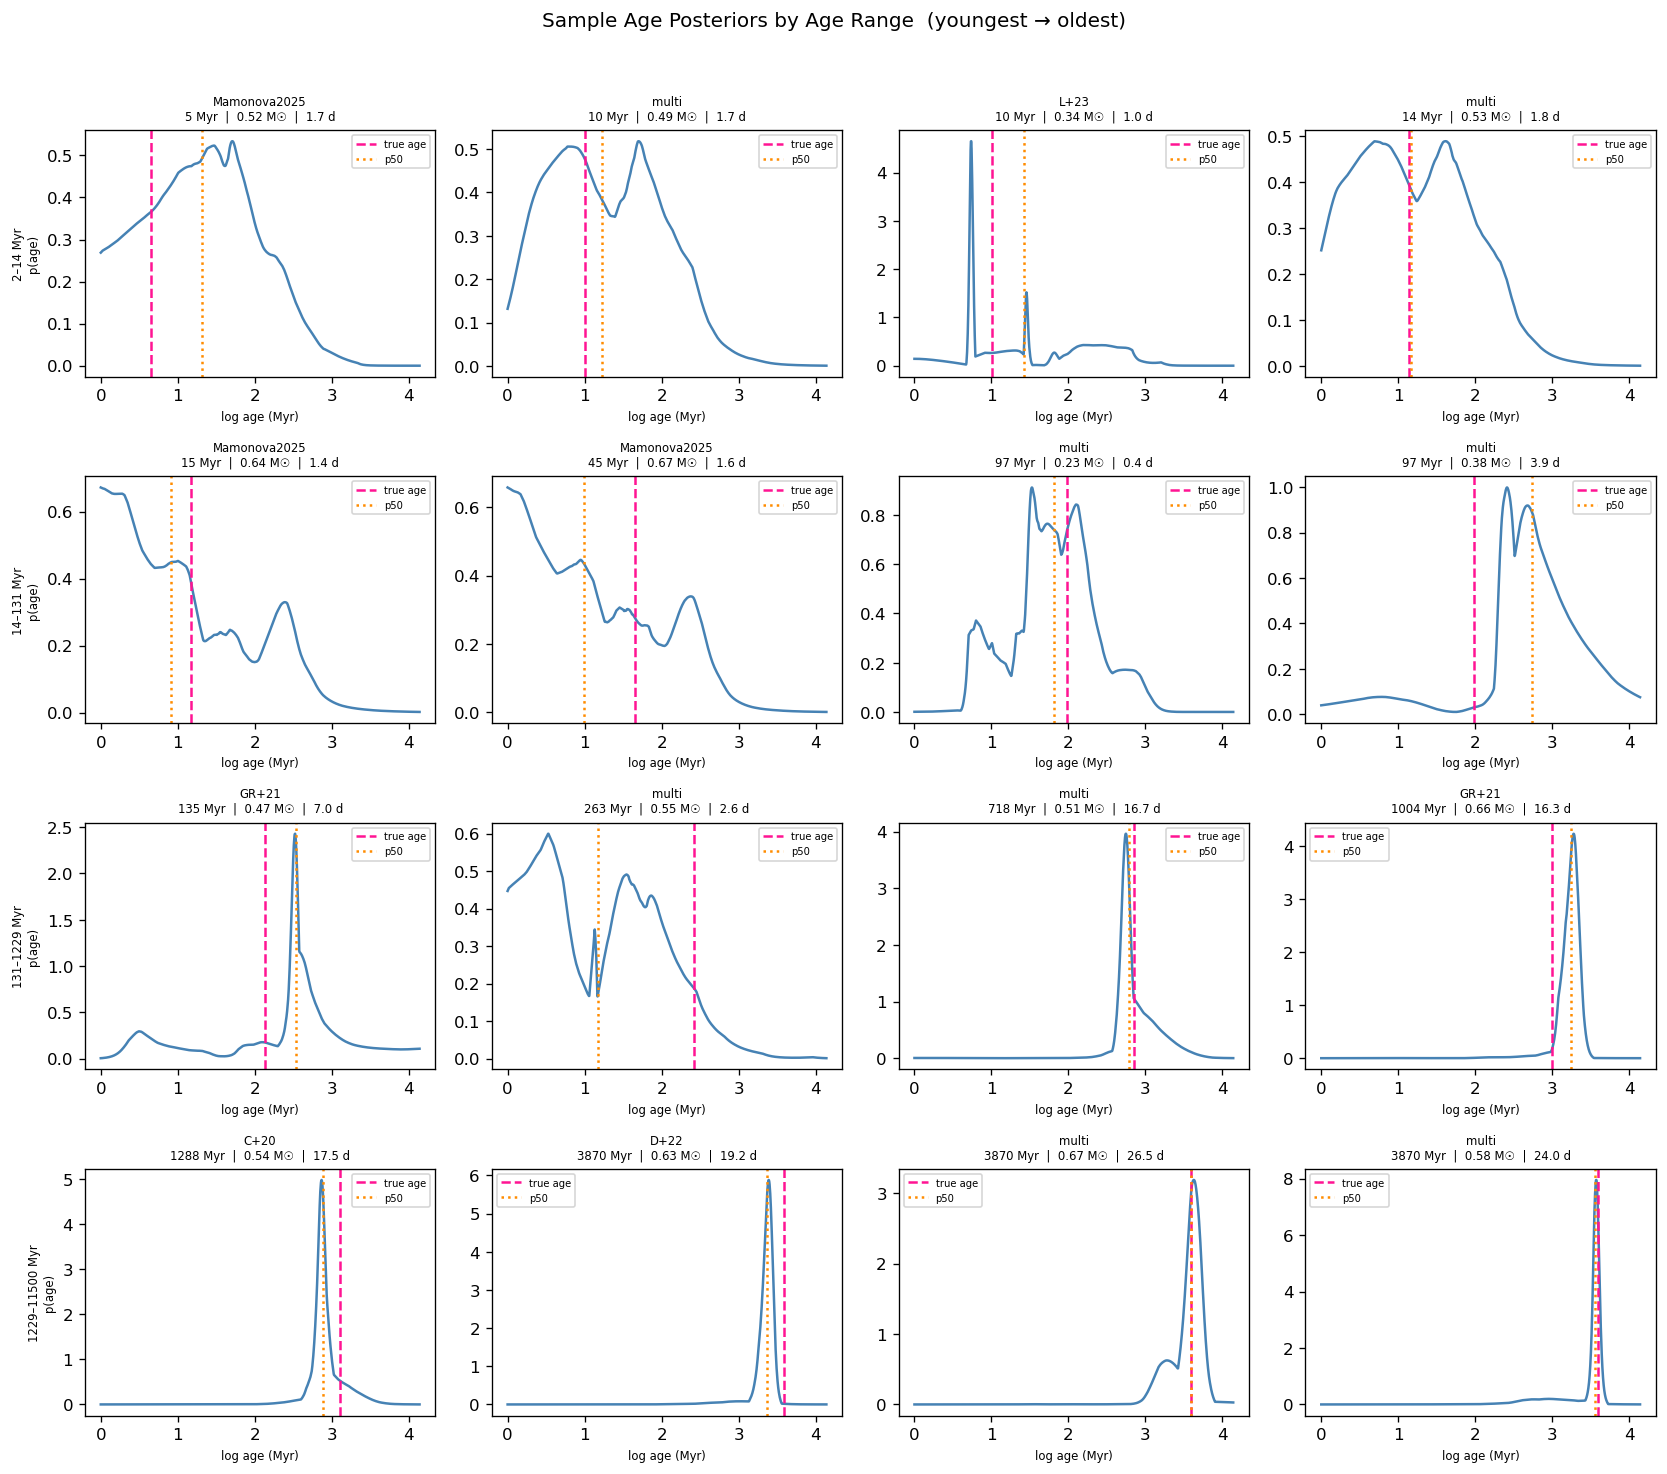

In [12]:
import importlib
import training.plots, training.report
importlib.reload(training.plots)
importlib.reload(training.report)
from training.plots import plot_posteriors_by_age

print('Posteriors shape:', posteriors_kfold.shape)
plot_posteriors_by_age(posteriors_kfold, LOGA_GRID, results_df, n_rows=4, n_cols=4)

## 6b. Posteriors near the fully convective boundary (0.3–0.4 M☉)

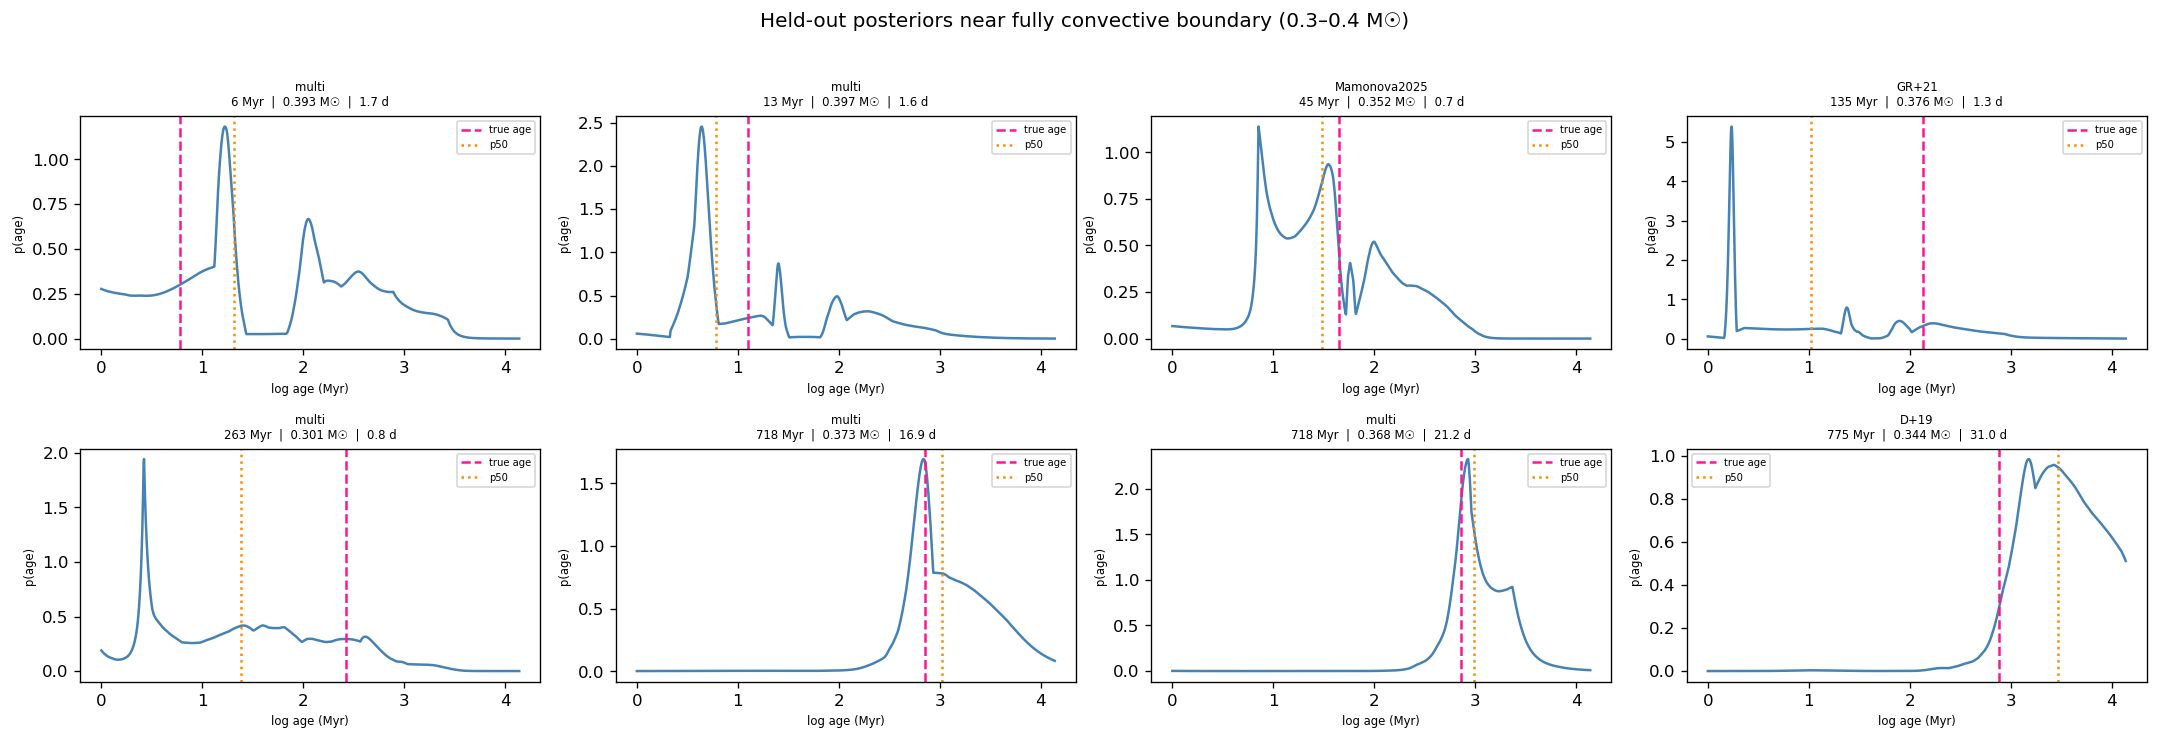

In [13]:
_field = {'MOCADB', 'Engle2023', 'LWRD', 'Pass2022'}
fc_mask = (results_df['mass_msun'] >= 0.3) & (results_df['mass_msun'] <= 0.4)
fc_df   = results_df[fc_mask].copy().reset_index(drop=True)
fc_pos  = np.where(fc_mask)[0]

is_cluster = ~fc_df['source_paper'].isin(_field)
pool_idx   = np.where(is_cluster)[0] if is_cluster.sum() >= 8 else np.arange(len(fc_df))
age_order  = pool_idx[np.argsort(fc_df.iloc[pool_idx]['log_age_myr'].values)]
pick       = age_order[np.linspace(0, len(age_order) - 1, 8, dtype=int)]

n_cols = 4
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6))
axes = axes.flatten()
for ax, i in zip(axes, pick):
    row      = fc_df.iloc[i]
    post_idx = fc_pos[i]
    ax.plot(LOGA_GRID, posteriors_kfold[post_idx], color='steelblue', lw=1.5)
    ax.axvline(row['log_age_myr'], color='deeppink', lw=1.5, ls='--', label='true age')
    ax.axvline(row['p50'], color='darkorange', lw=1.5, ls=':', label='p50')
    ax.set_title(f"{row['source_paper']}\n{10**row['log_age_myr']:.0f} Myr  |  {row['mass_msun']:.3f} M☉  |  {row['prot_days']:.1f} d", fontsize=7)
    ax.set_xlabel('log age (Myr)', fontsize=7)
    ax.set_ylabel('p(age)', fontsize=7)
    ax.legend(fontsize=6)
plt.suptitle('Held-out posteriors near fully convective boundary (0.3–0.4 M☉)', y=1.02)
plt.tight_layout()
plt.show()

## 7. P(Ro | age, τ_cE) heatmap per cluster

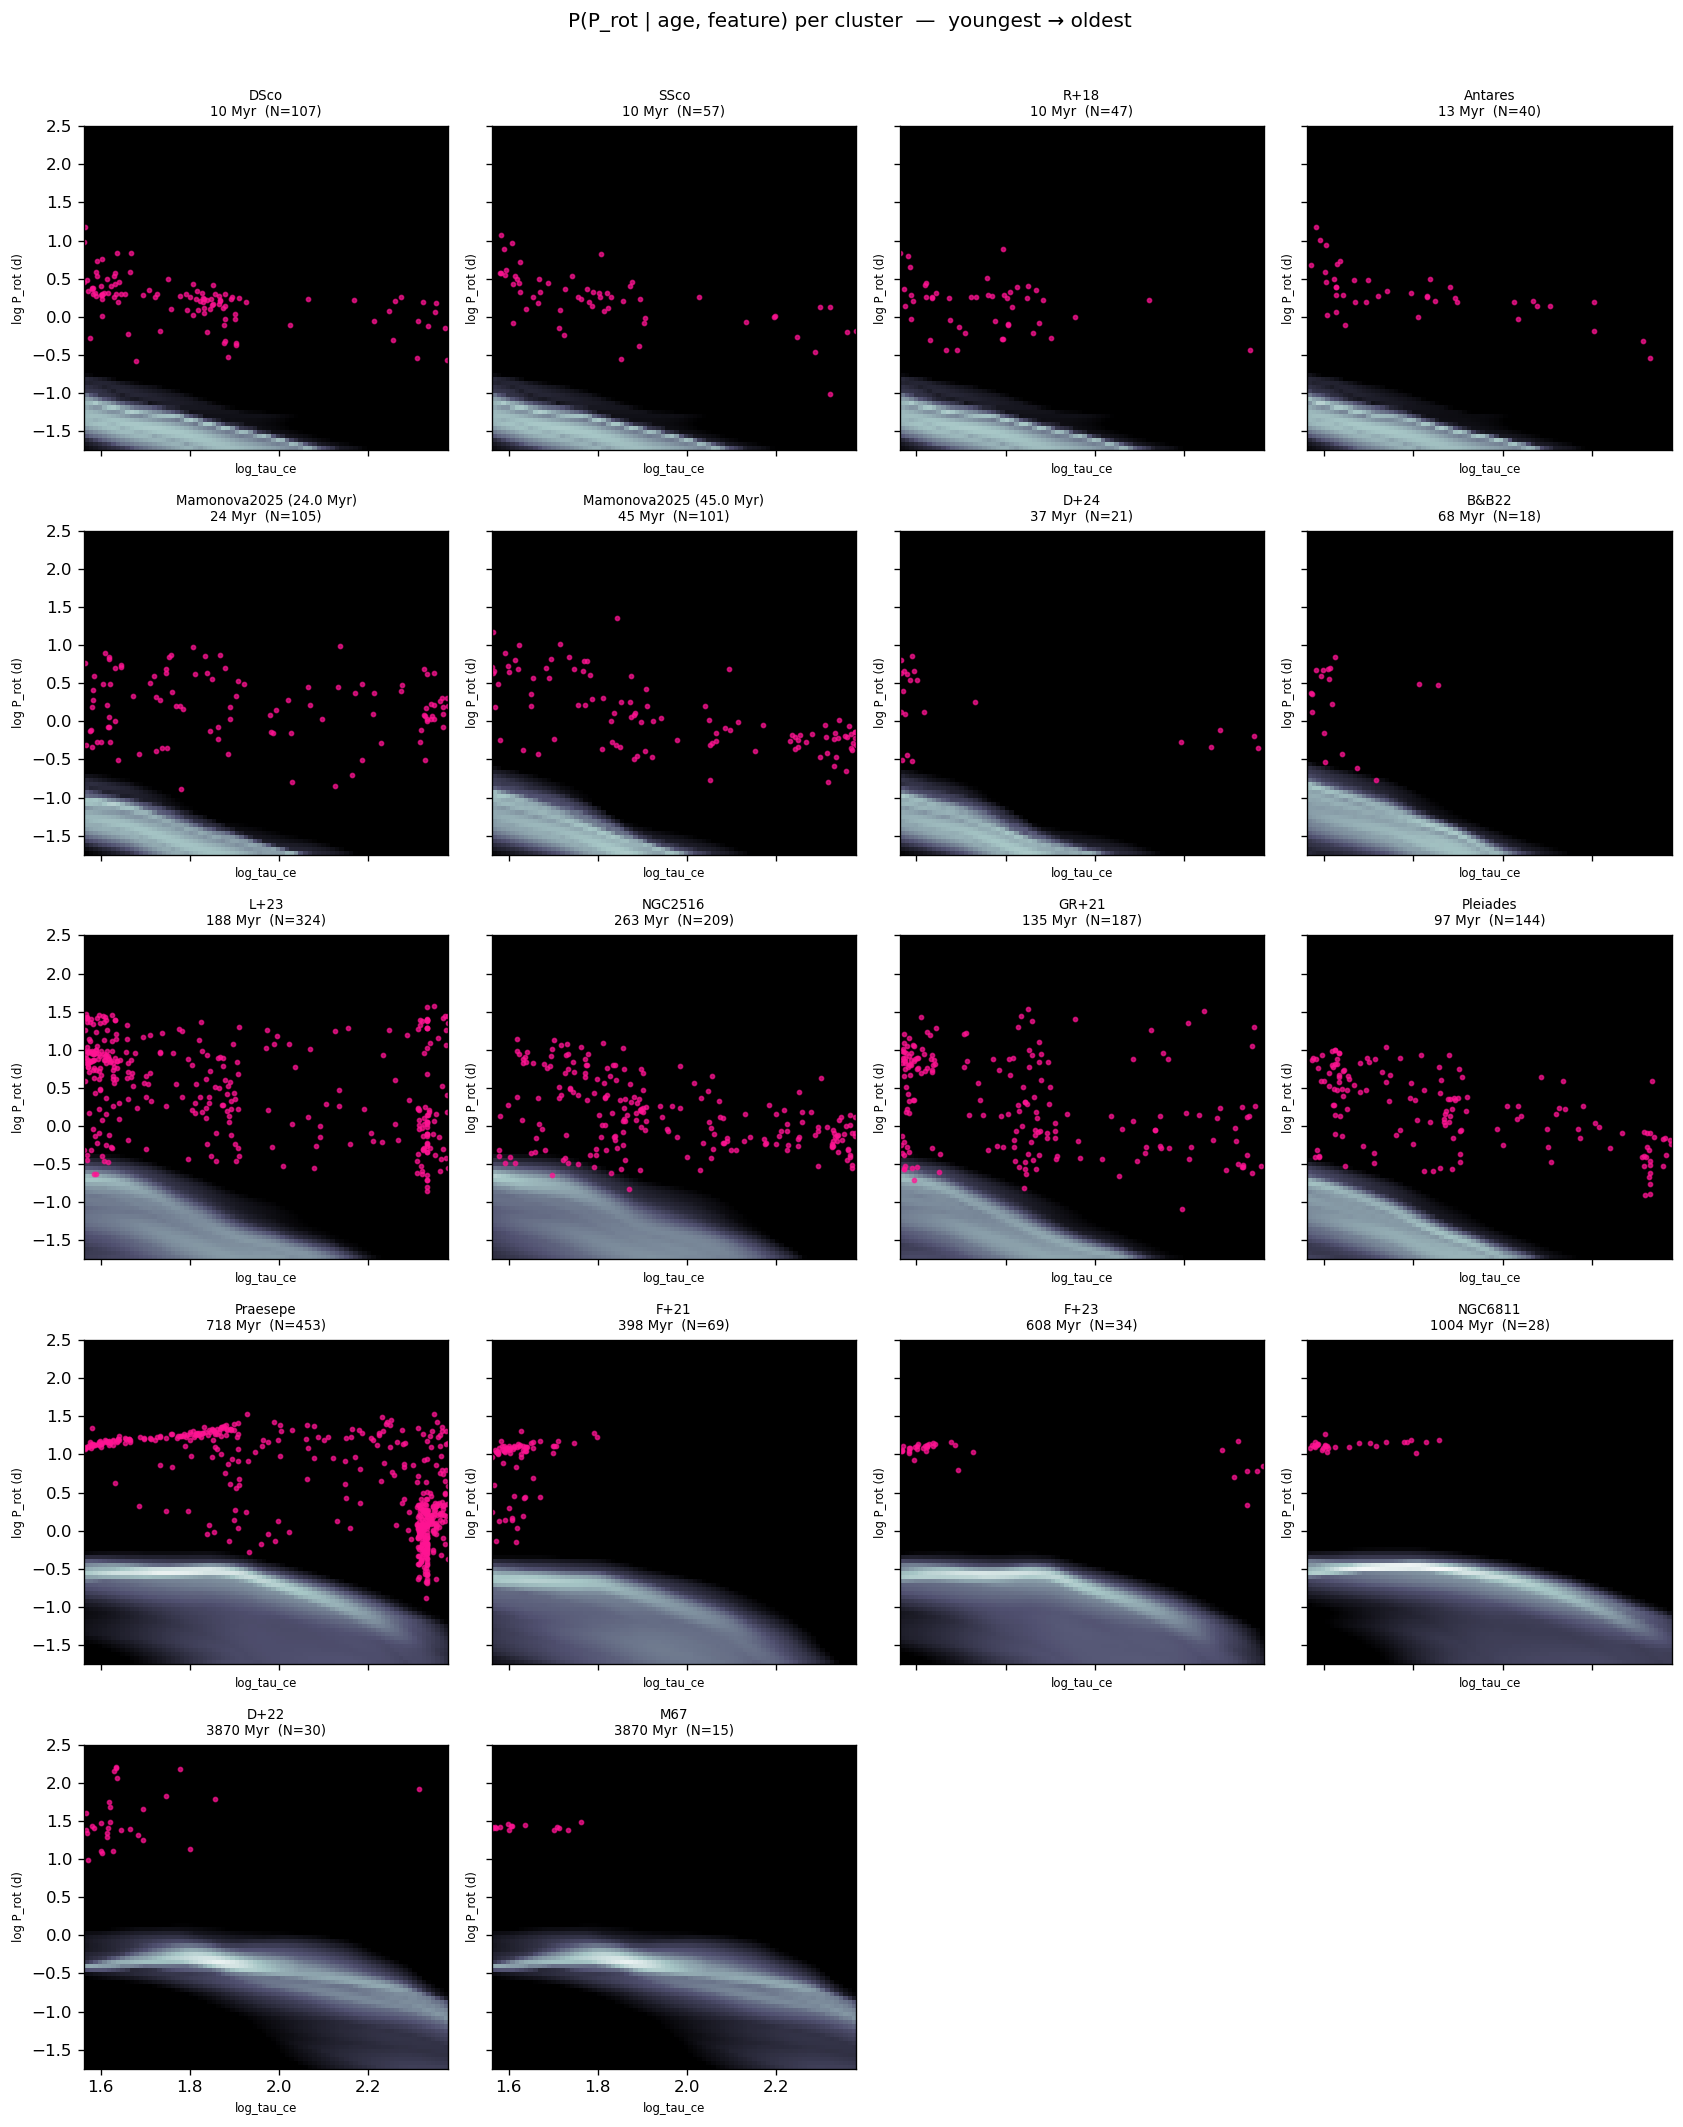

In [9]:
import importlib
import training.data, training.plots, training.report
importlib.reload(training.data)
importlib.reload(training.plots)
importlib.reload(training.report)
from training.data   import load_training
from training.report import prot_space_report

df = load_training('../../cf_data/training_stars.csv', drop_nan_age_err=True)
prot_space_report(fold_flows, df, COND_COLS, fold_scalers)

## 8. Summary statistics

In [10]:
print('=== 1B Rossby — K-fold validation summary ===')
print(f'N stars evaluated : {len(results_df)}')
print(f'Median residual   : {results_df["residual_dex"].median():.3f} dex')
print(f'Median precision  : {(results_df["p84"] - results_df["p16"]).median():.3f} dex')
print(f'% within 0.3 dex  : {(results_df["residual_dex"].abs() < 0.3).mean()*100:.1f}%')
results_df.groupby('fold')[['residual_dex']].agg(['median', 'std'])

=== 1B Rossby — K-fold validation summary ===
N stars evaluated : 5846
Median residual   : -0.292 dex
Median precision  : 1.477 dex
% within 0.3 dex  : 34.2%


residual_dex          
           median       std
fold                       
0       -0.264593  0.765129
1       -0.311955  0.802140
2       -0.306698  0.732601
3       -0.311573  0.718636
4       -0.274724  0.783634

## 9. Save models and results

In [11]:
import os
os.makedirs('../../outputs/1b_rossby', exist_ok=True)

results_df.to_csv('../../outputs/1b_rossby/results.csv', index=False)
np.save('../../outputs/1b_rossby/posteriors_kfold.npy', posteriors_kfold)
np.save('../../outputs/1b_rossby/loss_curves.npy', np.array(loss_curves, dtype=object), allow_pickle=True)

for i, (flow, scaler) in enumerate(zip(fold_flows, fold_scalers)):
    torch.save(flow.state_dict(), f'../../outputs/1b_rossby/fold{i}_flow.pt')
    with open(f'../../outputs/1b_rossby/fold{i}_scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

print('Saved to outputs/1b_rossby/')

Saved to outputs/1b_rossby/
